# Hi-C basics — `pairs → .cool → balanced → heatmap`

This tutorial exercises the `epione.hic` scaffold end-to-end on a
**synthetic** contact matrix, so the pipeline runs without any real
Hi-C data download. The data generator writes a 4DN-compatible
`.pairs` file whose contacts decay with distance along a power-law,
which is enough to drive the ICE balance step to a sensible weight
vector and produce a legible off-diagonal-decay heatmap.

For a real biological walkthrough (compartments / TADs / loops on
Drosophila Hi-C), see `t_hic_analysis.ipynb` (Phase 2, coming next).

### What this exercises

| Step | epione call |
| --- | --- |
| pairs.gz → .cool   | `epi.hic.pairs_to_cool` (wraps `cooler cload pairs`) |
| .cool → balanced   | `epi.hic.balance_cool` (ICE via `cooler.balance_cooler`) |
| region heatmap     | `epi.hic.plot_contact_matrix` |

## 1 · Setup + synthetic pairs generator

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysam
import cooler

import epione as epi
epi.pl.plot_set()

OUT = pathlib.Path('result') / 't_hic_basics'
OUT.mkdir(parents=True, exist_ok=True)

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



In [2]:
def make_synthetic_pairs(out_dir: pathlib.Path,
                          n_pairs: int = 50_000,
                          chrom: str = 'chr_synt',
                          size: int = 5_000_000,
                          seed: int = 0) -> tuple[pathlib.Path, pathlib.Path]:
    '''Write a 4DN `.pairs.gz` with power-law decaying intra-chrom contacts.'''
    rng = np.random.default_rng(seed)
    sizes = out_dir / 'chrom.sizes'
    sizes.write_text(f'{chrom}\t{size}\n')

    d    = rng.exponential(30_000, n_pairs).astype(int)
    pos1 = rng.integers(0, size - d.max() - 1, n_pairs)
    pos2 = pos1 + d
    mask = pos2 < size
    pos1, pos2 = pos1[mask], pos2[mask]

    pairs = out_dir / 'synt.pairs'
    with pairs.open('w') as fh:
        fh.write('## pairs format v1.0\n')
        fh.write(f'#chromsize: {chrom} {size}\n')
        fh.write('#columns: readID chrom1 pos1 chrom2 pos2 strand1 strand2\n')
        for i, (p1, p2) in enumerate(zip(pos1, pos2)):
            fh.write(f'r{i}\t{chrom}\t{p1}\t{chrom}\t{p2}\t+\t+\n')
    pairs_gz = out_dir / 'synt.pairs.gz'
    pysam.tabix_compress(str(pairs), str(pairs_gz), force=True)
    pairs.unlink()
    return pairs_gz, sizes

pairs_gz, chrom_sizes = make_synthetic_pairs(OUT)
print(f'pairs  → {pairs_gz}  ({pairs_gz.stat().st_size/1024:.1f} KB)')
print(f'sizes  → {chrom_sizes}  ({chrom_sizes.read_text().strip()})')

pairs  → result/t_hic_basics/synt.pairs.gz  (507.9 KB)
sizes  → result/t_hic_basics/chrom.sizes  (chr_synt	5000000)


## 2 · `pairs → .cool`

`epi.hic.pairs_to_cool` streams the pairs file into a binned contact
matrix via `cooler cload pairs`. A 50-kb resolution on a 5-Mb
chromosome gives 100 bins per side — small enough to display cleanly
and big enough that power-law decay is visible.

In [3]:
cool_path = OUT / 'synt.cool'
epi.hic.pairs_to_cool(
    pairs_path=pairs_gz,
    chrom_sizes=chrom_sizes,
    out_cool=cool_path,
    binsize=50_000,
)

c = cooler.Cooler(str(cool_path))
print(f'bins    : {len(c.bins()[:])}')
print(f'pixels  : {int(c.pixels()[:].shape[0]):,}')
print(f'chromsize: {dict(c.chromsizes)}')

bins    : 100
pixels  : 478
chromsize: {'chr_synt': np.int32(5000000)}


## 3 · ICE balance

`balance_cool` runs cooler's iterative correction in place and writes
the `bins/weight` column. The returned dict exposes whether it
converged, how many bins got masked for low coverage, and the
rescaling scale.

In [4]:
stats = epi.hic.balance_cool(
    cool_path,
    mad_max=10, min_nnz=1, min_count=0,
    ignore_diags=0, max_iters=500, tol=1e-5,
)
stats

{'converged': True,
 'n_iters': 0,
 'n_masked': 8,
 'scale': 0.03071060906863446,
 'var': 1.2954780650192965e-06,
 'reused_existing': True}

## 4 · Pre- vs post-balance heatmap

Render the same chromosome twice: raw counts first, then the
balanced matrix (which divides each cell by the outer product of its
two bin weights).

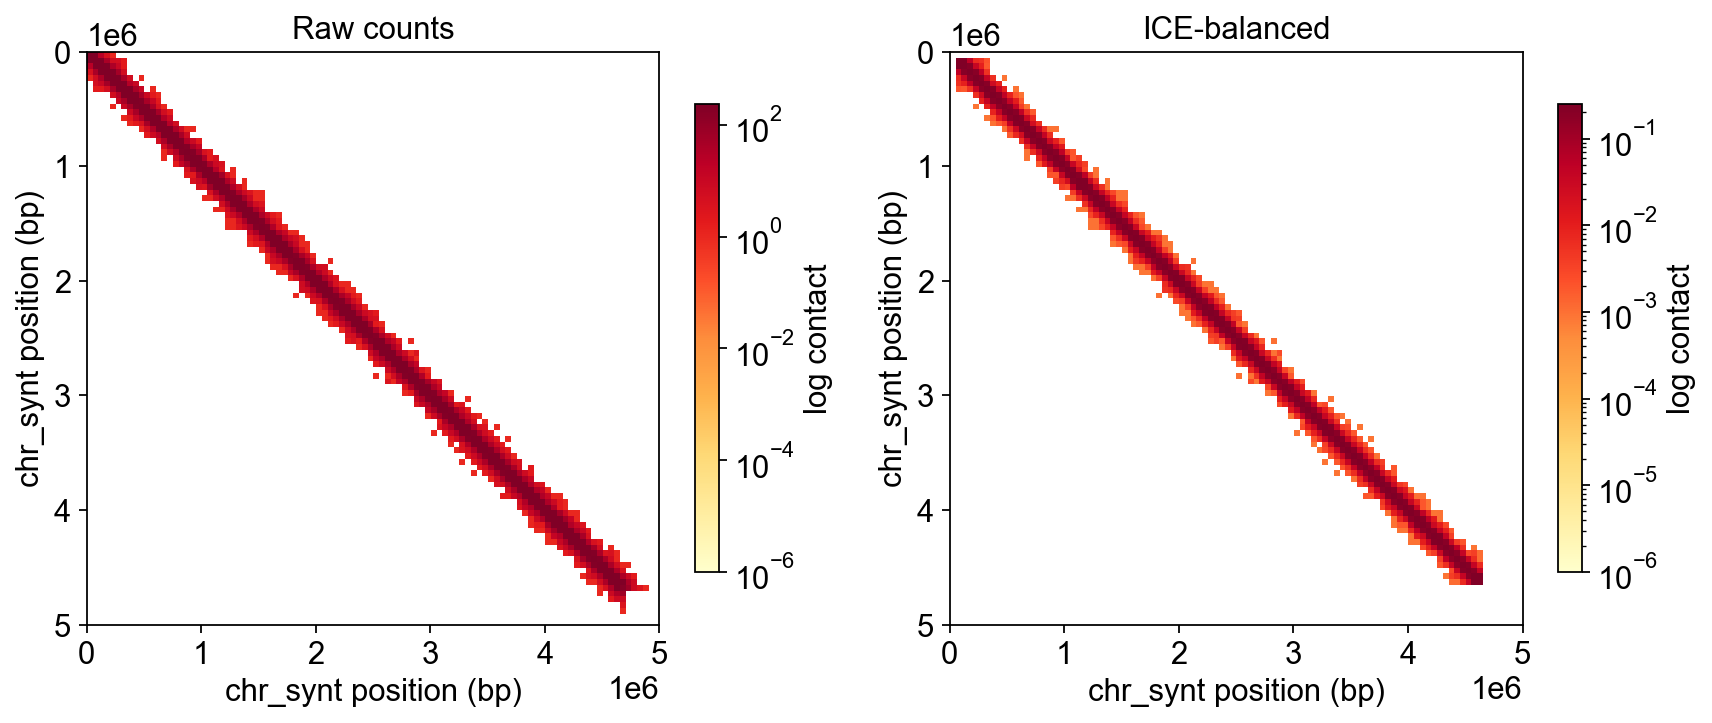

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

epi.hic.plot_contact_matrix(
    cool_path, region='chr_synt',
    balance=False, log=True,
    ax=axes[0], title='Raw counts',
)
epi.hic.plot_contact_matrix(
    cool_path, region='chr_synt',
    balance=True, log=True,
    ax=axes[1], title='ICE-balanced',
)
plt.tight_layout()
plt.show()

## 5 · Contact-decay curve P(s)

The most important Hi-C QC plot. For each diagonal offset *s*
(= genomic separation in bin units), average all intra-chromosome
cells at that offset, then plot on log-log axes. A healthy library
shows a roughly linear decay with slope around −1; a flat plateau or
non-monotone shape signals contamination, undersampled libraries, or
aggressive over-balancing. On our synthetic power-law-distance
contacts the curve should be monotonically decreasing.

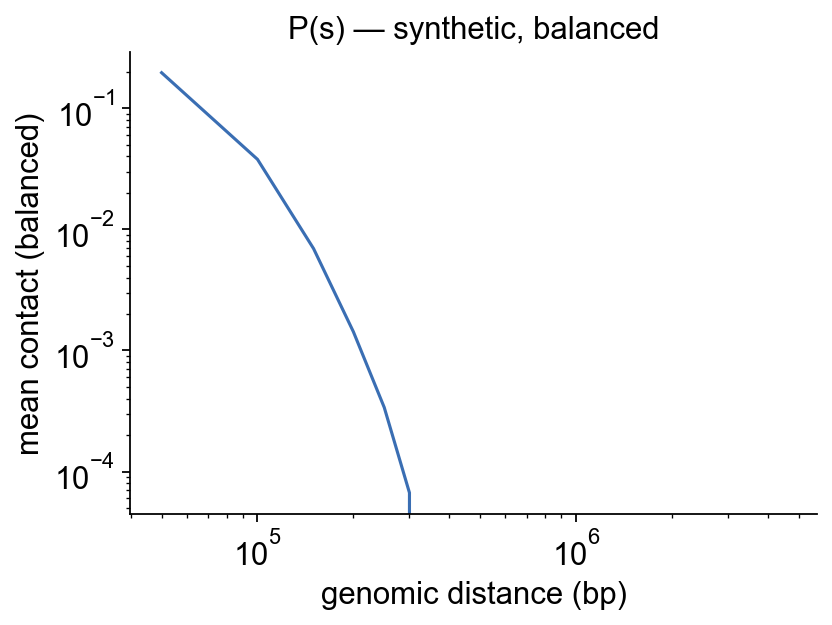

,chrom,offset_bin,distance_bp,mean_contact,n_pairs
0,chr_synt,0,0,0.259958,92
1,chr_synt,1,50000,0.196703,91
2,chr_synt,2,100000,0.037865,90
3,chr_synt,3,150000,0.006931,89
4,chr_synt,4,200000,0.001427,88
5,chr_synt,5,250000,0.000338,87
6,chr_synt,6,300000,0.000067,86
7,chr_synt,7,350000,0.000000,85


In [6]:
fig, ax, decay_df = epi.hic.plot_decay_curve(
    cool_path, balance=True, figsize=(5.5, 3.8),
    title='P(s) — synthetic, balanced',
)
plt.show()
decay_df.head(8)

## 6 · Per-bin coverage + ICE weights

`plot_coverage` lays out two panels side-by-side: the per-bin total
contact coverage on the left (the input the balance step sees) and
the resulting ICE weight distribution on the right (the output ICE
emits). Bins whose weight is NaN are masked from the balanced
matrix (`mad_max` outliers + `min_nnz` low-coverage cutoffs).

If the right panel is missing entirely you forgot to balance — see
`balance_cool` in §3.

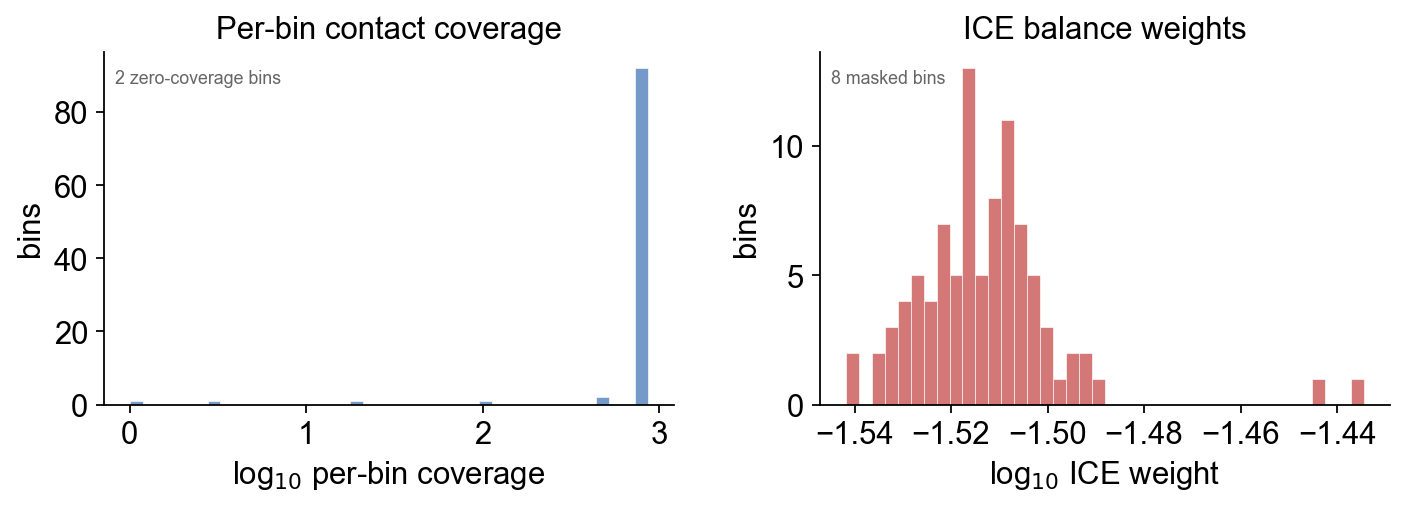

In [7]:
fig, axes = epi.hic.plot_coverage(
    cool_path, balance=False, bins=40, figsize=(9, 3.4),
)
plt.show()

## 7 · Zoomed-in region heatmap

`plot_contact_matrix` takes any UCSC-style range, so once you
identify a region of interest from a chromosome-wide view you can
zoom right in. Here we slice to the first 1.5 Mb of the synthetic
chromosome to show the off-diagonal pattern in more detail.

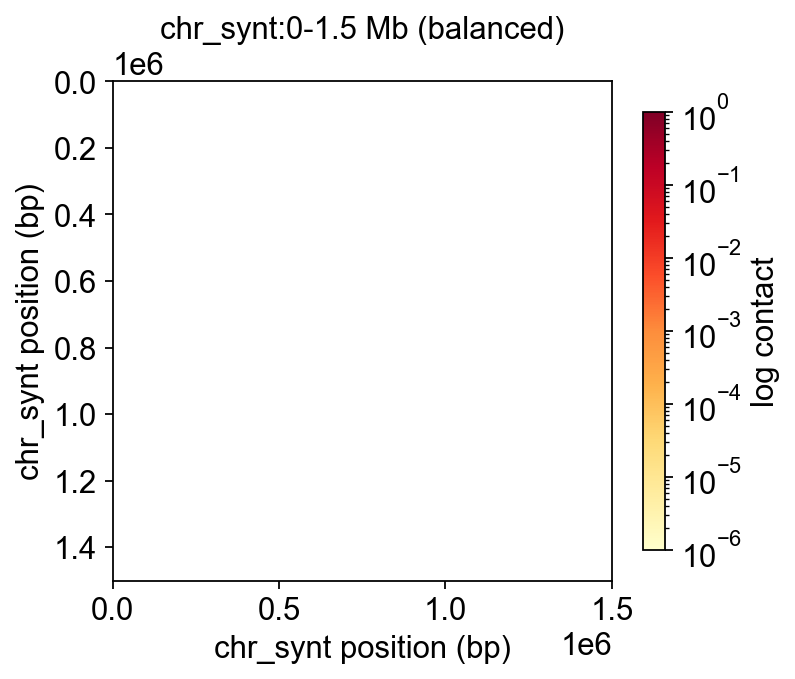

In [8]:
fig, ax, _ = epi.hic.plot_contact_matrix(
    cool_path,
    region='chr_synt:0-1_500_000',
    balance=True, log=True,
    figsize=(5.0, 4.5),
    title='chr_synt:0-1.5 Mb (balanced)',
)
plt.show()

### Summary + next

Phase 1 lands four `epi.hic` plotting / IO entry points:

| Call | Output |
| --- | --- |
| `pairs_to_cool` | `.cool` matrix at chosen binsize |
| `balance_cool` | ICE weights + diagnostics dict, written in place |
| `plot_contact_matrix` | log-scale region heatmap |
| `plot_decay_curve` | P(s) genomic-distance decay (the canonical QC) |
| `plot_coverage` | per-bin coverage + ICE weight histograms |

Phase 2 (`t_hic_analysis.ipynb`) swaps this synthetic for the Galaxy
HiCExplorer Drosophila dataset and adds:

- **A / B compartments** via eigendecomposition (`hicPCA`-equivalent).
- **TAD boundaries** via insulation score.
- **Loop calling** via dot-finder.
- A composite *"Hi-C triangle + TAD boundaries + ATAC/ChIP tracks"*
  panel plugged into `epi.bulk.bigwig.plot_track_multi`.